# Spam Classifier — Exploratory Data Analysis

Source: `data/processed/emails.parquet` (parsed from the SpamAssassin public corpus)

## Setup / Load Data

In [1]:
import pandas as pd

DATA_PATH = "../data/processed/emails.parquet"

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(6100, 10)


,label,source_folder,filename,from,to,subject,date,reply_to,received_count,body
0,ham,easy_ham,0001.ea7e79d3153e7469e7a9c3e0af6a357e,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,Re: New Sequences Window,"Thu, 22 Aug 2002 18:26:25 +0700",,10,"Date: Wed, 21 Aug 2002 10:54:46 -05..."
1,ham,easy_ham,0002.b3120c4bcbf3101e661161ee7efcb8bf,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...",[zzzzteana] RE: Alexander,"Thu, 22 Aug 2002 12:46:18 +0100",zzzzteana@yahoogroups.com,10,"Martin A posted:\nTassos Papadopoulos, the Gre..."
2,ham,easy_ham,0003.acfc5ad94bbd27118a0d8685d18c89dd,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,[zzzzteana] Moscow bomber,"Thu, 22 Aug 2002 13:52:38 +0100",zzzzteana@yahoogroups.com,9,Man Threatens Explosion In Moscow \n\nThursday...
3,ham,easy_ham,0004.e8d5727378ddde5c3be181df593f1712,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,[IRR] Klez: The Virus That Won't Die,"Thu, 22 Aug 2002 09:15:25 -0400",,7,Klez: The Virus That Won't Die\n \nAlready the...
4,ham,easy_ham,0005.8c3b9e9c0f3f183ddaf7592a11b99957,Tony Nugent <tony@linuxworks.com.au>,Exmh Users Mailing List <exmh-users@example.com>,Re: Insert signature,"Thu, 22 Aug 2002 23:36:32 +1000",exmh-users@example.com,11,"On Wed Aug 21 2002 at 15:46, Ulises Ponce wrot..."


## 1. Class Balance

SpamAssassin is imbalanced toward ham — quantify the split overall and per `source_folder`. This matters for metric choice later (accuracy will be misleading; prefer precision/recall/F1 on the spam class).

In [2]:
print("Overall counts:")
print(df["label"].value_counts())
print()
print("Overall proportions:")
print(df["label"].value_counts(normalize=True).round(3))

print("\nCounts by source_folder:")
print(df.groupby("source_folder")["label"].value_counts())

Overall counts:
label
ham     4202
spam    1898
Name: count, dtype: int64

Overall proportions:
label
ham     0.689
spam    0.311
Name: proportion, dtype: float64

Counts by source_folder:
source_folder  label
easy_ham       ham      2551
easy_ham_2     ham      1401
hard_ham       ham       250
spam           spam      501
spam_2         spam     1397
Name: count, dtype: int64


## 2. Email Length & HTML vs Plain-Text

Distribution of email body length (spam vs ham), and the ratio of HTML-sourced vs plain-text bodies by label.

Matplotlib is building the font cache; this may take a moment.


        count         mean          std   min     25%     50%      75%  \
label                                                                    
ham    4202.0  1864.257258  5249.198203  47.0  535.25   979.0  1679.75   
spam   1898.0  2394.203372  6081.129686   0.0  674.00  1117.0  2047.00   

            max  
label            
ham    194824.0  
spam   126335.0  


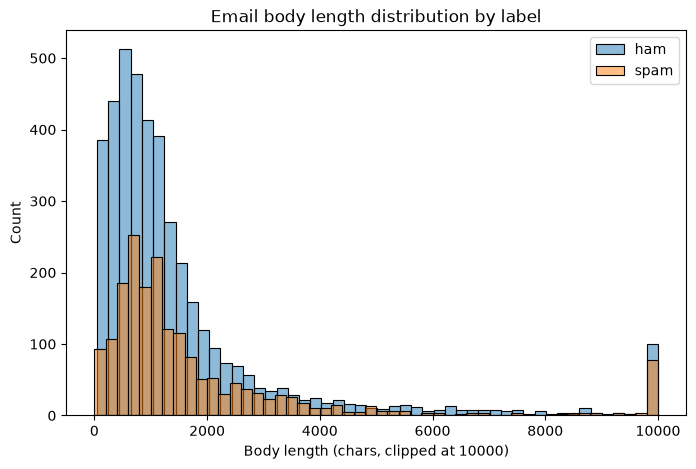


Content-Type counts by label:
label  content_type               
ham    text/plain                     3883
       text/html                       122
       multipart/signed                111
       multipart/alternative            58
       multipart/mixed                  21
       multipart/related                 4
       multipart/report                  3
spam   text/plain                      820
       text/html                       770
       multipart/alternative           169
       multipart/mixed                  99
       multipart/related                39
       text/plain charset=us-ascii       1
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import email
import email.policy
from pathlib import Path

# --- Body length distribution by label ---
df["body_len"] = df["body"].fillna("").str.len()
print(df.groupby("label")["body_len"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in df["label"].unique():
    sns.histplot(df.loc[df["label"] == lbl, "body_len"].clip(upper=10000),
                 bins=50, label=lbl, alpha=0.5, ax=ax)
ax.set_xlabel("Body length (chars, clipped at 10000)")
ax.set_title("Email body length distribution by label")
ax.legend()
plt.show()

# --- HTML vs plain-text ratio by label (from top-level Content-Type header) ---
RAW_DIR = Path("../data/raw")

def get_content_type(source_folder, filename):
    path = RAW_DIR / source_folder / filename
    with open(path, "rb") as f:
        msg = email.message_from_binary_file(f, policy=email.policy.default)
    return msg.get_content_type()

df["content_type"] = df.apply(lambda r: get_content_type(r["source_folder"], r["filename"]), axis=1)

print("\nContent-Type counts by label:")
print(df.groupby("label")["content_type"].value_counts())

## 3. Subject & Sender Domain Patterns

Common spam subject patterns (keywords, punctuation/caps usage) and sender/reply-to domain patterns.

In [4]:
import re
from collections import Counter

# --- Common words in subjects, spam vs ham ---
def tokenize(text):
    return re.findall(r"[a-z]{3,}", text.lower())

for lbl in df["label"].unique():
    subjects = df.loc[df["label"] == lbl, "subject"].fillna("")
    words = Counter(w for s in subjects for w in tokenize(s))
    print(f"\nTop 15 subject words — {lbl}:")
    for word, count in words.most_common(15):
        print(f"  {word:15s} {count}")

# --- Subject style signals: all-caps ratio, exclamation marks ---
df["subject_upper_ratio"] = df["subject"].fillna("").apply(
    lambda s: sum(1 for c in s if c.isupper()) / len(s) if len(s) > 0 else 0
)
df["subject_exclaim_count"] = df["subject"].fillna("").str.count("!")

print("\nSubject uppercase ratio by label:")
print(df.groupby("label")["subject_upper_ratio"].describe())

print("\nSubject exclamation count by label:")
print(df.groupby("label")["subject_exclaim_count"].describe())

# --- Sender domain patterns ---
def extract_domain(addr):
    if not isinstance(addr, str):
        return None
    match = re.search(r"@([\w\.-]+)", addr)
    return match.group(1).lower() if match else None

df["from_domain"] = df["from"].apply(extract_domain)

print("\nTop 10 sender domains — spam:")
print(df.loc[df["label"] == "spam", "from_domain"].value_counts().head(10))

print("\nTop 10 sender domains — ham:")
print(df.loc[df["label"] == "ham", "from_domain"].value_counts().head(10))


Top 15 subject words — ham:
  ilug            586
  the             568
  for             378
  razor           338
  users           246
  and             204
  satalk          185
  with            178
  was             174
  spambayes       145
  new             143
  spam            129
  ouch            121
  use             112
  apt             111

Top 15 subject words — spam:
  your            307
  you             199
  for             178
  the             175
  free            164
  and             98
  adv             81
  ilug            68
  get             67
  mortgage        62
  money           56
  home            55
  business        54
  with            53
  now             52

Subject uppercase ratio by label:
        count      mean       std  min       25%       50%       75%  max
label                                                                    
ham    4202.0  0.128126  0.094362  0.0  0.060606  0.108696  0.173913  0.9
spam   1898.0  0.180172  0.206902 

## 4. Missing / Malformed Headers & Parsing Edge Cases

Document header completeness (missing From/Subject/Reply-To, etc.) and the parsing edge cases handled in `parse_emails.py` (e.g. malformed charsets).

In [5]:
for col in ["from", "to", "subject", "date", "reply_to", "body"]:
    n_missing = df[col].isna().sum()
    n_empty = (df[col].fillna("").str.strip() == "").sum()
    print(f"{col:10s} missing={n_missing:5d}  empty_or_missing={n_empty:5d}")

print("\nExact duplicate body rows:", df["body"].duplicated().sum())

from       missing=    0  empty_or_missing=    4
to         missing=    0  empty_or_missing=  217
subject    missing=    0  empty_or_missing=   20
date       missing=    0  empty_or_missing=    3
reply_to   missing=    0  empty_or_missing= 4076
body       missing=    0  empty_or_missing=   17

Exact duplicate body rows: 424
